In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic

jax.config.update("jax_enable_x64", True)
%matplotlib inline

## Make fake data:

Some fake data that looks like our abundance trends with z:

In [47]:
ndata = 10_000

key = jr.key(42)
keys = jr.split(key, 4)
fake_z = jr.normal(keys[0], ndata) * 2.0
fake_mg_fe = jr.normal(keys[1], ndata) * 0.5 + 0.2 * jnp.abs(fake_z)
#fake_mg_fe = jr.normal(keys[1], ndata) * 0.5 + 0.2 * jnp.abs(fake_z - 1.0)
fake_mg_fe_err = jr.uniform(keys[2], ndata, minval=0.05, maxval=0.1)
fake_mg_fe += jr.normal(keys[3], ndata) * fake_mg_fe_err

In [48]:
z_bins = np.arange(-5, 5 + 1e-3, 0.1)

stat1 = binned_statistic(
    fake_z, fake_mg_fe / fake_mg_fe_err**2, bins=z_bins, statistic="sum"
)
stat2 = binned_statistic(fake_z, 1 / fake_mg_fe_err**2, bins=z_bins, statistic="sum")

stat_std = binned_statistic(fake_z, fake_mg_fe, bins=z_bins, statistic='std')
stat_count = binned_statistic(fake_z, fake_mg_fe, bins=z_bins, statistic='count')
intrinsic_scatter = stat_std.statistic / np.sqrt(stat_count.statistic)

mean_mg_fe = stat1.statistic / stat2.statistic
mean_mg_fe_err = np.sqrt(1 / stat2.statistic + intrinsic_scatter**2)
z_binc = 0.5 * (z_bins[1:] + z_bins[:-1])

Text(0, 0.5, '[Mg/Fe]')

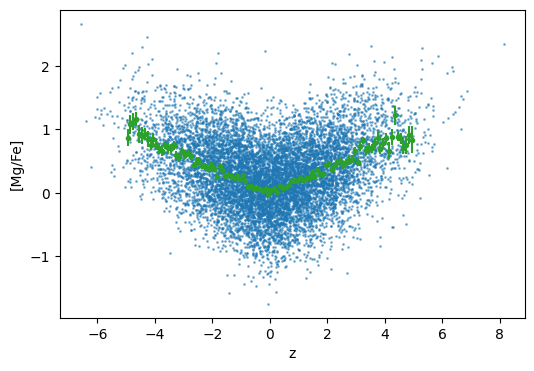

In [49]:
plt.figure(figsize=(6, 4))
plt.scatter(fake_z, fake_mg_fe, s=1, alpha=0.5)
plt.errorbar(
    z_binc, mean_mg_fe, yerr=mean_mg_fe_err, color="C2", linestyle="", marker="."
)
plt.xlabel("z")
plt.ylabel("[Mg/Fe]")

## Fit a mixture of sech^2 models:

The ${\rm sech}^2(z)$ profile is a common function used to model the vertical density distribution of stars in galactic disks. This might be TMI, but it comes from solving the Poisson equation assuming an isothermal and equilibrium distribution function for the stars in a thin disk. Real galactic disks are not isothermal or in equilibrium, and the Milky Way's vertical distribution typically requires a mixture of two or more profiles to get a good fit because of the thin/thick disk structure. 

So we'll try out a model to prodict [Mg/Fe] as a function of z that is a mixture of two ${\rm sech}^2$ profiles. Defining $Y = [{\rm Mg/Fe}]$, then the model is:
$$
Y(z) = 
    A_1 \, \textrm{sech}^2\left(\frac{z}{h_1}\right) + 
    A_2 \, \textrm{sech}^2\left(\frac{z}{h_2}\right)
$$
and a reminder that:
$$
    \textrm{sech}(x) = \frac{1}{\cosh(x)}
$$

The parameters $A_1$ and $A_2$ are the amplitudes of the two components, and $h_1$ and $h_2$ are the scale heights.

In [50]:
def mixture_of_sech2(z, A1, A2, h1, h2, z0):
    # z0 shifts the dip's center along z; the minimum of the curve sits at z = z0
    dz = z - z0
    return A1 * (1 / jnp.cosh(dz / h1)) ** 2 + A2 * (1 / jnp.cosh(dz / h2)) ** 2

Let's plot what this looks like compared to a parabola in z for some choice of parameters (motivated by the rough thin/thick disk scale heights):

[(-3.0, 1.0)]

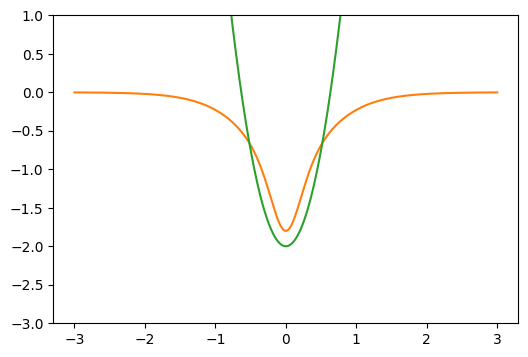

In [51]:
z_grid = np.linspace(-3, 3, 1000)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    z_grid,
    # z0=0.0 keeps this preview curve centered at z=0 (just for visualization)
    mixture_of_sech2(z_grid, -1.0, -0.8, 0.3, 0.8, 0.0),
    color="C1",
    label="mixture of sech^2",
)
ax.plot(z_grid, 5 * z_grid**2 - 2, color="C2", label="parabola")
ax.set(ylim=(-3, 1))

### Infer the parameters of the mixture of sech^2 model using numpyro:

So far, we have been using optimization to find the best-fit parameters of our models. But now we're going to introduce a new concept: Markov Chain Monte Carlo (MCMC) sampling. This is a powerful technique for inferring the _posterior probability distribution_ of model parameters given some data and a likelihood function. We can expand on this more next time we meet, but the power of this is that it gives us a way to quantify the uncertainty in our parameter estimates.

In [52]:
import arviz as az

import numpyro
import numpyro.distributions as dist
import numpyro.infer as infer

In [97]:
def model(data):
    A1 = numpyro.sample("A1", dist.TruncatedNormal(-1.0, 5.0, low=None, high=0.0))
    A2 = numpyro.sample("A2", dist.TruncatedNormal(-1.0, 5.0, low=None, high=0.0))
    h1 = numpyro.sample("h1", dist.Uniform(0.1, 1.0))
    d_h2 = numpyro.sample("d_h2", dist.Uniform(0.1, 5.0))
    h2 = h1 + d_h2
    # z0 = midplane location; prior centered at 0 with ~1 kpc spread
    z0 = numpyro.sample("z0", dist.Normal(0.0, 1.0))           
    offset = numpyro.sample("offset", dist.Normal(0.0, 5.0))

    # pass z0 so the model can shift the dip away from z=0 if the data prefer it
    model_y = mixture_of_sech2(data["z"], A1, A2, h1, h2, z0) + offset   

    numpyro.sample("obs", dist.Normal(model_y, data["mg_fe_err"]), obs=data["mg_fe"])

In [98]:
sampler = infer.MCMC(
    infer.NUTS(model, dense_mass=True),
    num_warmup=1000,
    num_samples=1000,
    num_chains=2,
)
data = {"z": z_binc, "mg_fe": mean_mg_fe, "mg_fe_err": mean_mg_fe_err}
sampler.run(jr.PRNGKey(0), data=data)
samples = sampler.get_samples()

/var/folders/6v/s_h7sm_95_j5djq7d1sz66vr0000gn/T/ipykernel_96439/2636324607.py:1: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  sampler = infer.MCMC(
sample: 100%|█| 2000/2000 [00:03<00:00, 555.14it/s, 15 steps of size 1.33e-01. a
sample: 100%|█| 2000/2000 [00:01<00:00, 1005.81it/s, 15 steps of size 1.99e-01. 


In [99]:
idata = az.from_numpyro(sampler)
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
A1,-0.154,0.029,-0.211,-0.104,0.001,0.001,433.0,415.0,1.01
A2,-1.324,0.174,-1.649,-1.034,0.010,0.006,262.0,399.0,1.00
d_h2,3.993,0.507,3.207,4.975,0.032,0.016,219.0,201.0,1.00
h1,0.733,0.130,0.527,0.993,0.005,0.003,711.0,717.0,1.00
offset,1.501,0.189,1.192,1.859,0.012,0.006,242.0,381.0,1.01
z0,-0.005,0.026,-0.051,0.044,0.001,0.001,1327.0,1304.0,1.00


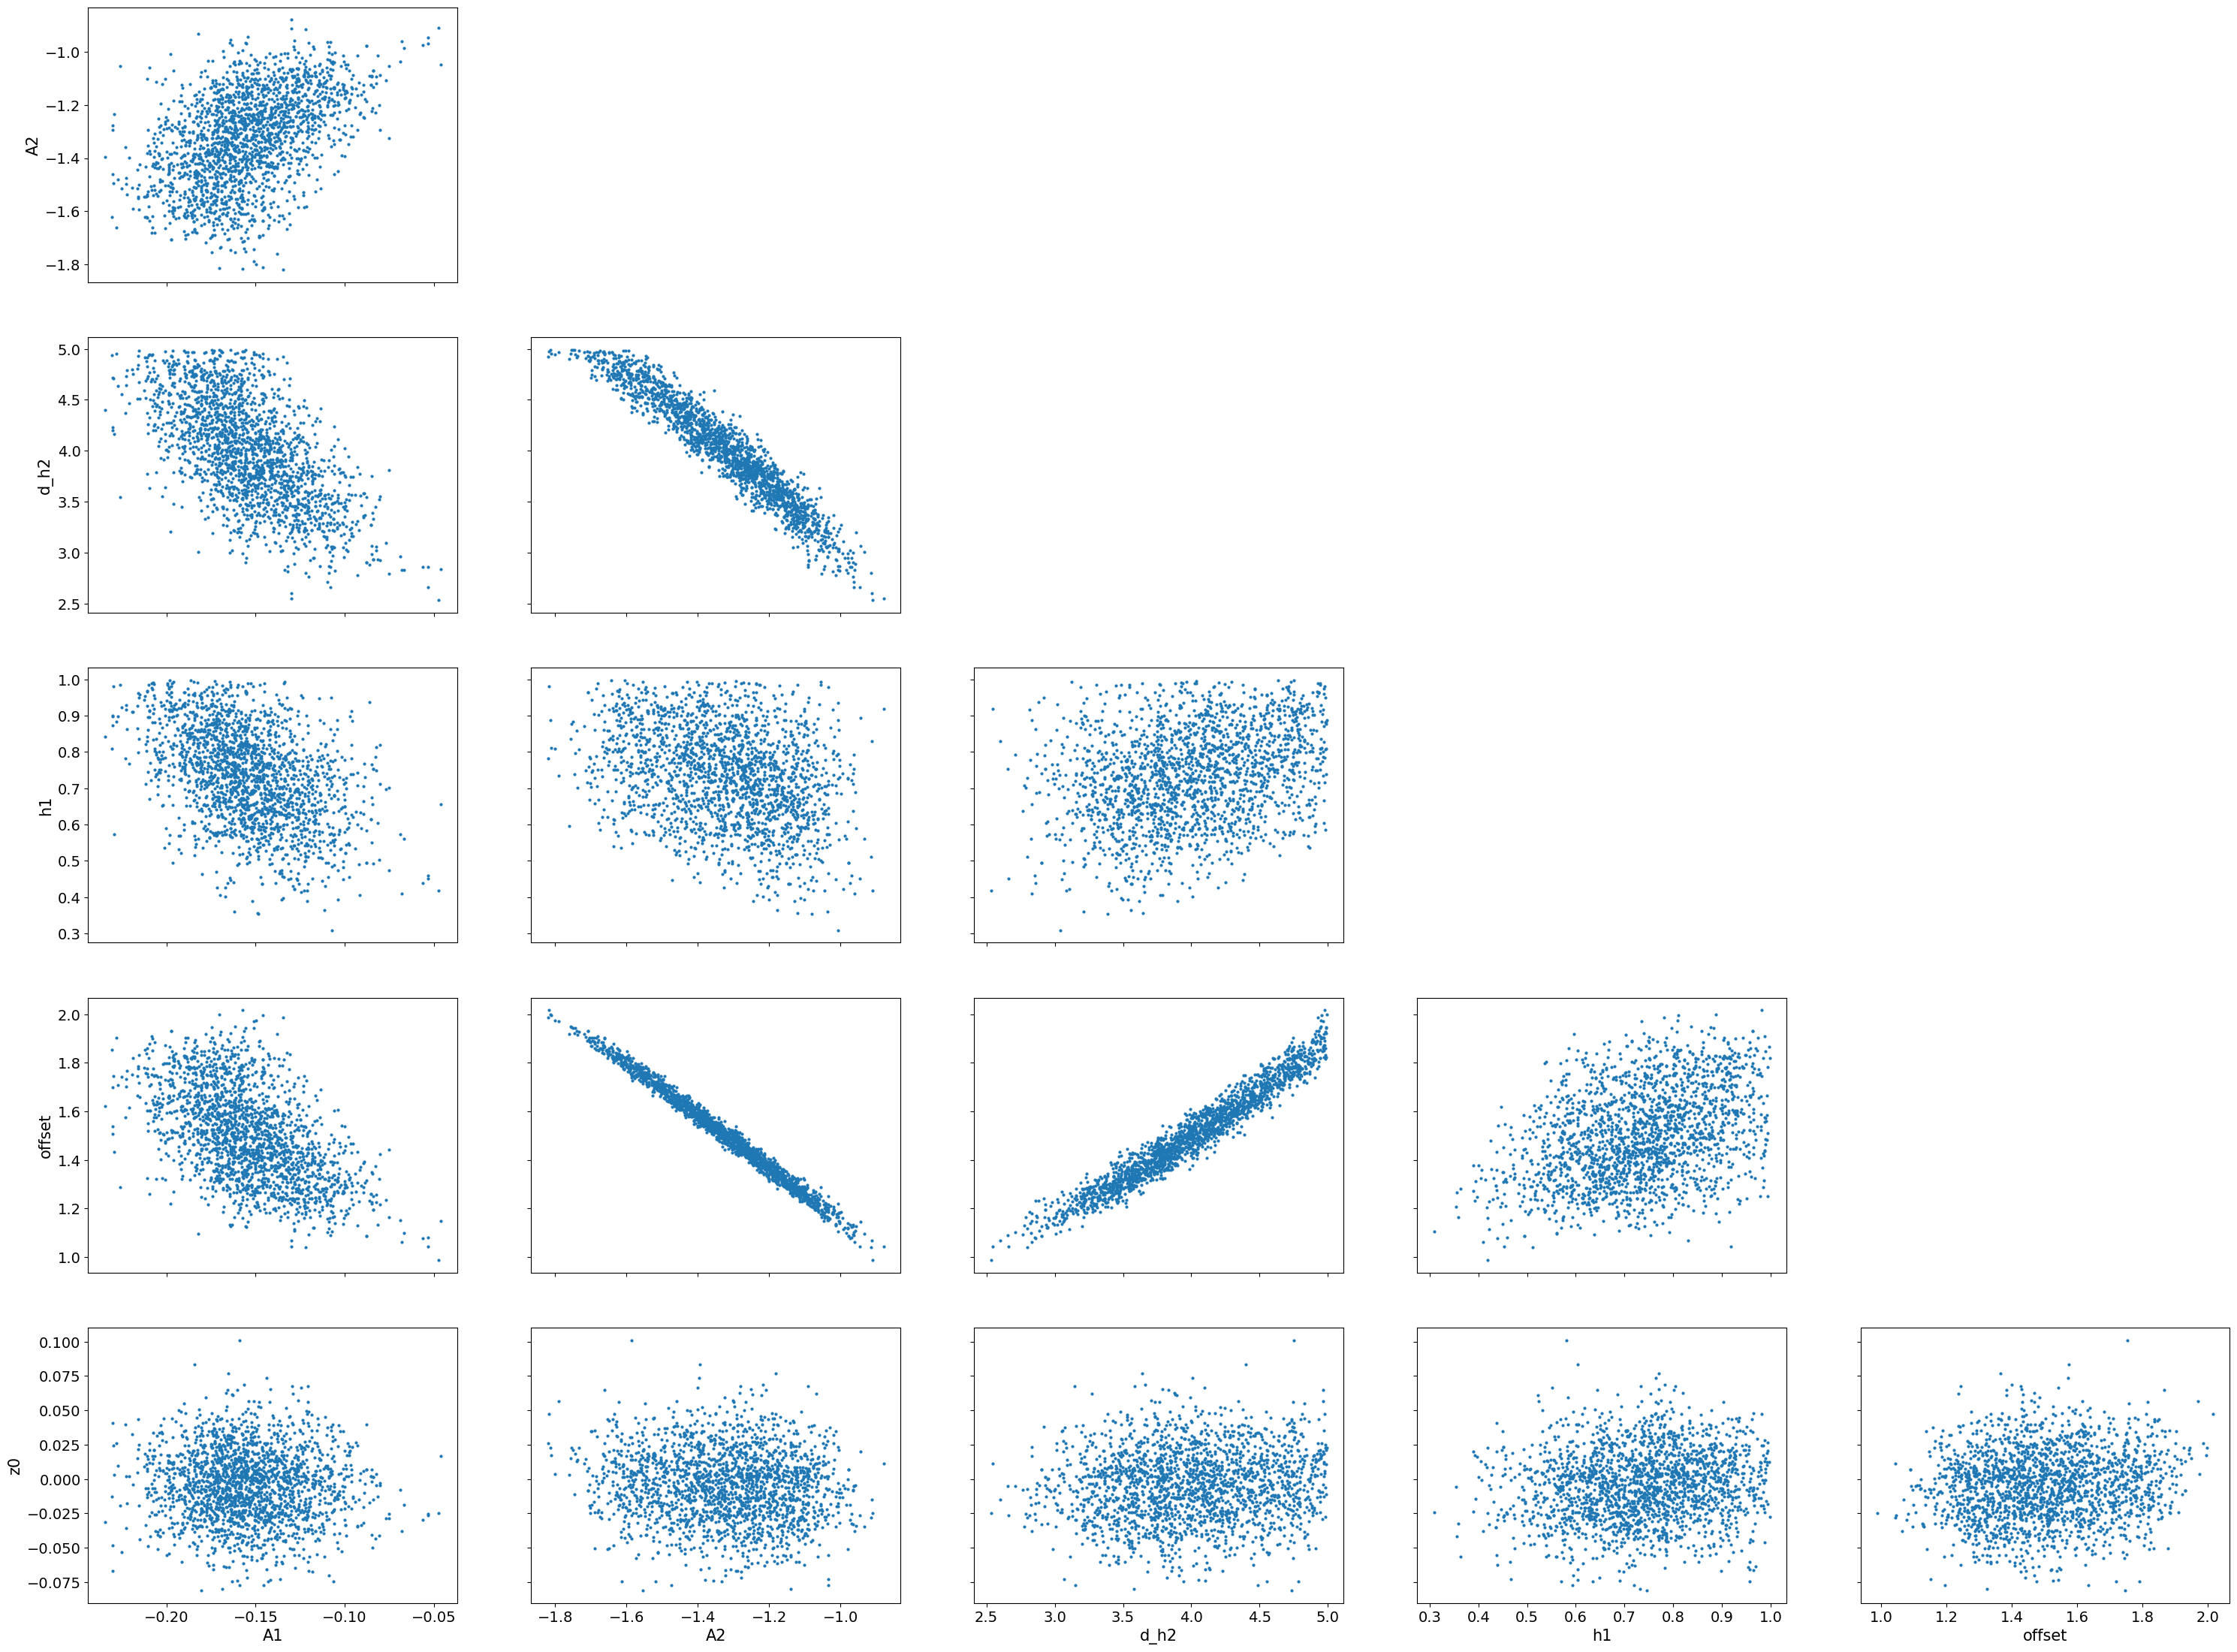

In [100]:
_ = az.plot_pair(idata, marginals=False)

Text(0, 0.5, '[Mg/Fe]')

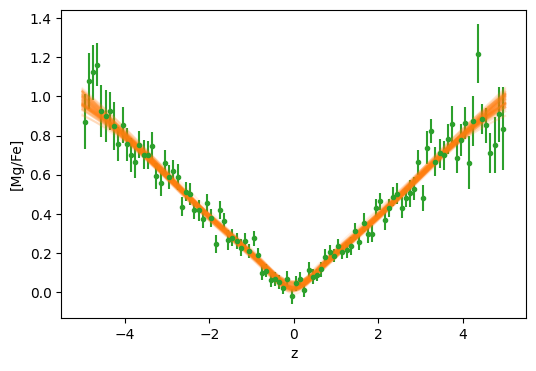

In [103]:
z_grid = np.linspace(-5, 5, 1000)

plt.figure(figsize=(6, 4))
plt.errorbar(
    z_binc, mean_mg_fe, yerr=mean_mg_fe_err, color="C2", linestyle="", marker="."
)

# Plot draws from the posterior predictive distribution:
for i in range(100):
    A1 = samples["A1"][i]
    A2 = samples["A2"][i]
    h1 = samples["h1"][i]
    h2 = h1 + samples["d_h2"][i]
    z0 = samples["z0"][i] # each posterior draw has its own midplane location
    y_pred = mixture_of_sech2(z_grid, A1, A2, h1, h2, z0) + samples["offset"][i]
    plt.plot(z_grid, y_pred, color="C1", alpha=0.1, marker='')
    
plt.xlabel("z")
plt.ylabel("[Mg/Fe]")

In [107]:
import numpy as np
print(f"z0 median = {np.median(samples['z0']):+.4f}")
print(f"z0 stddev = {np.std(samples['z0']):.3f}")

SNR_z0 = np.abs(np.median(samples['z0']) / np.std(samples['z0']))
print(f"SNR = {SNR_z0:.3f}")

z0 median = -0.0042
z0 stddev = 0.026
SNR = 0.162


So this model clearly does a better job of fitting the simulated data than the parabola, but still misses a bit toward the edges. We might need to add another or even more components to the model to get an even better fit, but you could try using this model already on the real data.

## Gaussian mixture model

Instead of summing sech^2 profiles, we could also just sum Gaussians. For now, I can't think of a good reason why this would be better than summing sech^2 profiles, so we can just stick with that for now. But if you wanted to explore / try it out, you could just replace the sech^2 function with a Gaussian mixture in the model definition and then re-run the inference. Something like:

In [13]:
def mixture_of_gaussians(z, A1, A2, h1, h2):
    return A1 * jnp.exp(-0.5 * (z / h1) ** 2) + A2 * jnp.exp(-0.5 * (z / h2) ** 2)